# Weight and Length

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as stats

full_df = pd.read_csv("newborn_health_monitoring_with_risk.csv")

# Only considering birth/final weights/lengths for now, so
df = full_df[full_df["age_days"]==30]
df

,baby_id,name,gender,gestational_age_weeks,birth_weight_kg,birth_length_cm,birth_head_circumference_cm,date,age_days,weight_kg,...,oxygen_saturation,feeding_type,feeding_frequency_per_day,urine_output_count,stool_count,jaundice_level_mg_dl,apgar_score,immunizations_done,reflexes_normal,risk_level
29,B001,Sara,Female,40.2,3.30,50.0,31.9,2025-01-08,30,4.26,...,97,Mixed,7,6,2,5.2,NaN,Yes,No,Healthy
59,B002,Nicole,Female,39.4,3.15,50.1,32.0,2025-08-26,30,4.05,...,97,Formula,10,9,0,2.1,NaN,Yes,No,Healthy
89,B003,James,Male,37.9,2.89,51.9,34.7,2024-11-15,30,3.82,...,98,Mixed,7,5,2,3.9,NaN,Yes,Yes,Healthy
119,B004,Donald,Male,38.2,2.87,53.3,34.4,2025-07-16,30,3.80,...,96,Mixed,12,5,0,2.7,NaN,Yes,Yes,Healthy
149,B005,Yvonne,Male,37.8,3.30,49.3,34.6,2025-02-11,30,4.15,...,98,Mixed,7,8,4,2.7,NaN,Yes,Yes,Healthy
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2879,B096,Vanessa,Female,38.9,2.83,49.7,35.5,2025-03-17,30,3.67,...,98,Mixed,10,4,2,1.7,NaN,Yes,Yes,Healthy
2909,B097,Jonathan,Female,38.5,3.00,54.4,33.1,2025-03-08,30,3.98,...,96,Formula,12,5,5,4.3,NaN,Yes,No,Healthy
2939,B098,Jennifer,Male,36.1,3.09,51.9,34.2,2024-12-23,30,3.99,...,97,Formula,8,6,2,2.2,NaN,Yes,Yes,Healthy
2969,B099,Terri,Female,38.5,3.81,46.5,32.8,2024-11-07,30,4.67,...,99,Breastfeeding,12,4,1,2.5,NaN,Yes,Yes,Healthy


## Weight/Length only

### Histograms

Here we look at the distribution of weights and lengths at birth and at day 30. We will use the Shapiro-Wilk test for normality at $\alpha=0.05$, i.e. for each of these quantities we have:
$$\begin{align*}
&H_0: \text{The quantity is Normally distributed.}\\
&H_1: \text{Not }H_0
\end{align*}$$

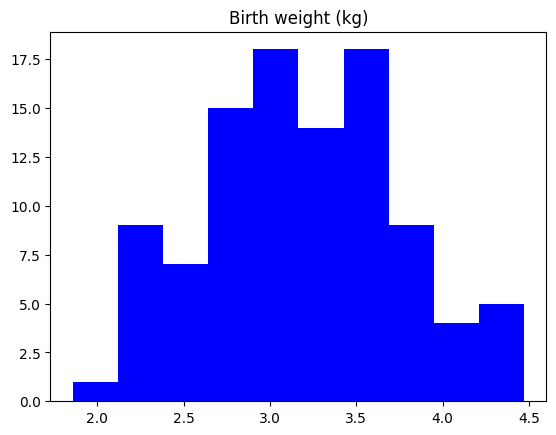

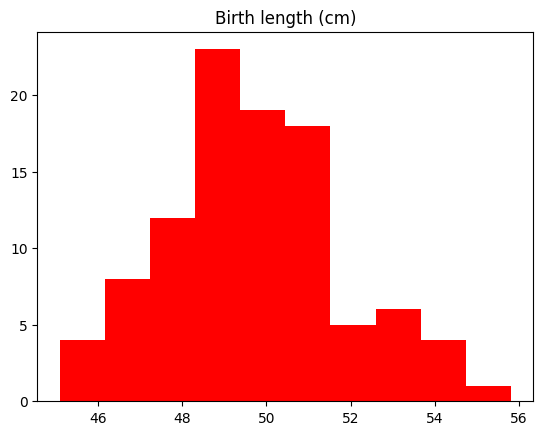

Birth weight p-value: 0.6027646477129023
Birth length p-value: 0.5400678197261051


In [3]:
plt.title("Birth weight (kg)")
plt.hist(df["birth_weight_kg"], color="blue")
plt.show()

plt.title("Birth length (cm)")
plt.hist(df["birth_length_cm"], color="red")
plt.show()

# Testing for normality for each:
birth_weight_shapiro = stats.shapiro(df["birth_weight_kg"])
birth_length_shapiro = stats.shapiro(df["birth_length_cm"])

print(f"Birth weight p-value: {birth_weight_shapiro[1]}")
print(f"Birth length p-value: {birth_length_shapiro[1]}")

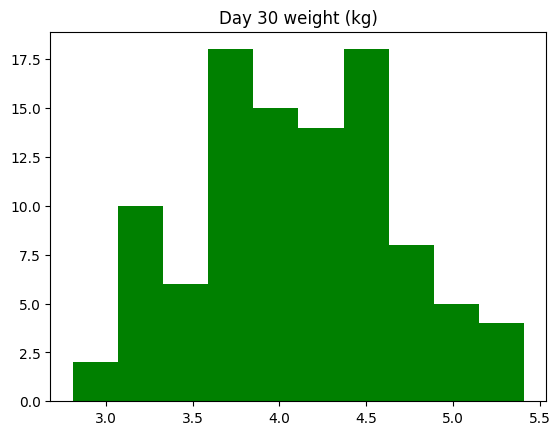

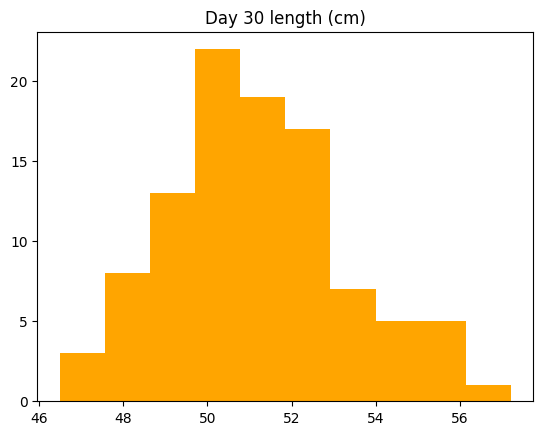

Day 30 weight p-value: 0.613311064831346
Day 30 length p-value: 0.45348490709511435


In [4]:
plt.title("Day 30 weight (kg)")
plt.hist(df["weight_kg"], color="green")
plt.show()

plt.title("Day 30 length (cm)")
plt.hist(df["length_cm"], color="orange")
plt.show()

# Testing for normality for each:
day30_weight_shapiro = stats.shapiro(df["weight_kg"])
day30_length_shapiro = stats.shapiro(df["length_cm"])

print(f"Day 30 weight p-value: {day30_weight_shapiro[1]}")
print(f"Day 30 length p-value: {day30_length_shapiro[1]}")

We do not reject the null hypothesis for all; they all appear normally distributed.

### PP Plots

See Module 1 Lecture 2 Slide 17.

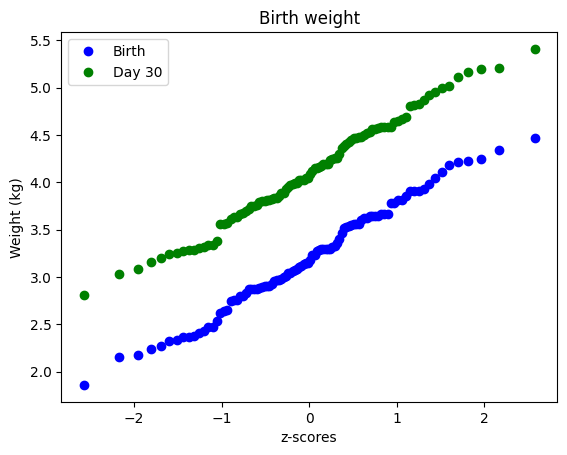

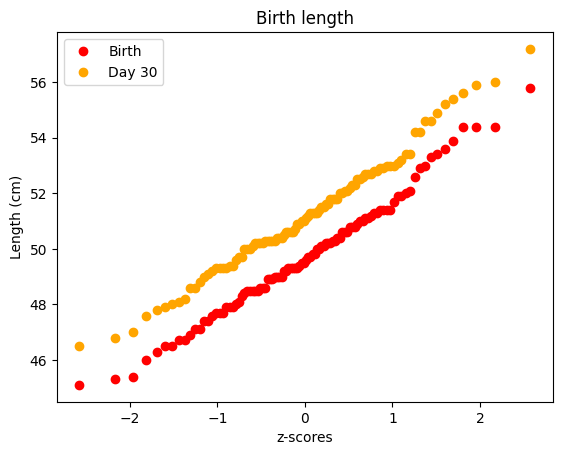

In [5]:
from scipy.stats import norm

sorted_birth_weights = np.sort(df["birth_weight_kg"])
sorted_birth_lengths = np.sort(df["birth_length_cm"])
sorted_day30_weights = np.sort(df["weight_kg"])
sorted_day30_lengths = np.sort(df["length_cm"])

n = len(sorted_birth_weights)
assert n == len(sorted_birth_lengths) and n == len(sorted_day30_weights) and n == len(sorted_day30_lengths)

# Step 1
quantiles = np.arange(0.5, n+0.5) / n
assert n == len(quantiles)

# Step 2
z_scores = norm.ppf(quantiles)

plt.title("Birth weight")
plt.plot(z_scores, sorted_birth_weights, "bo", label="Birth")
plt.plot(z_scores, sorted_day30_weights, "go", label="Day 30")
plt.xlabel("z-scores")
plt.ylabel("Weight (kg)")
plt.legend()
plt.show()

plt.title("Birth length")
plt.plot(z_scores, sorted_birth_lengths, "ro", label="Birth")
plt.plot(z_scores, sorted_day30_lengths, "o", color="orange", label="Day 30")
plt.xlabel("z-scores")
plt.ylabel("Length (cm)")
plt.legend()
plt.show()

The graphs appear relatively linear, further indicating that the samples seem to be approximately Normally distributed.

## Investigating Relationships

### Weight vs. Length

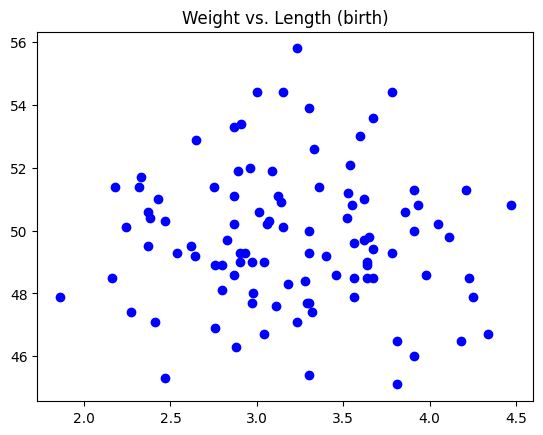

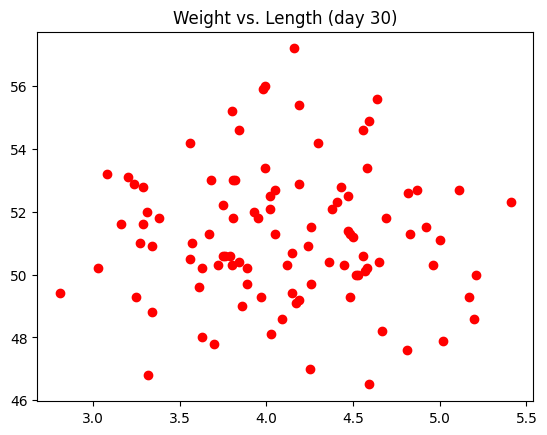

In [6]:
plt.title("Weight vs. Length (birth)")
plt.plot(df["birth_weight_kg"], df["birth_length_cm"], "bo")
plt.show()

plt.title("Weight vs. Length (day 30)")
plt.plot(df["weight_kg"], df["length_cm"], "ro")
plt.show()

In [7]:
np.corrcoef(df["birth_weight_kg"], df["birth_length_cm"])

array([[ 1.        , -0.04567043],
       [-0.04567043,  1.        ]])

In [8]:
np.corrcoef(df["weight_kg"], df["length_cm"])

array([[ 1.        , -0.03455737],
       [-0.03455737,  1.        ]])

Surprisingly, there doesn't seem to be much of a correlation between weight and length.

### Time

In [10]:
from sklearn.linear_model import LinearRegression

days = range(1, 31)

mean_weights = [np.mean(full_df[full_df["age_days"]==day]["weight_kg"]) for day in days]
mean_lengths = [np.mean(full_df[full_df["age_days"]==day]["length_cm"]) for day in days]

X = np.array(days).reshape(-1, 1)

weight_time_lr = LinearRegression().fit(X, mean_weights)
print("Weight vs. Time")
print(f"\tEquation: {weight_time_lr.coef_[0]} * days + {weight_time_lr.intercept_}")
print(f"\tR^2: {weight_time_lr.score(X, mean_weights)}")

length_time_lr = LinearRegression().fit(X, mean_lengths)
print("Length vs. Time")
print(f"\tEquation: {length_time_lr.coef_[0]} * days + {length_time_lr.intercept_}")
print(f"\tR^2: {length_time_lr.score(X, mean_lengths)}")

Weight vs. Time
	Equation: 0.029936974416017798 * days + 3.2057068965517246
	R^2: 0.9996750158147863
Length vs. Time
	Equation: 0.05008943270300316 * days + 49.731613793103456
	R^2: 0.9986409338624067


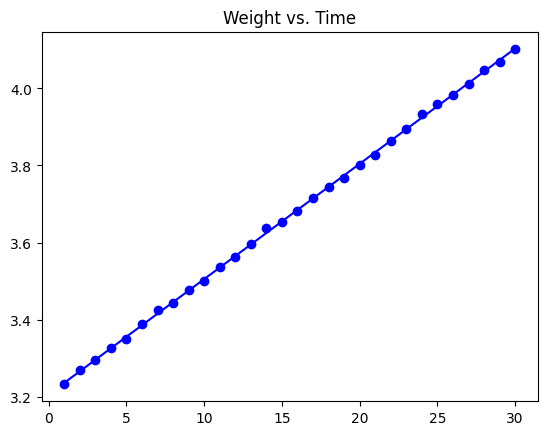

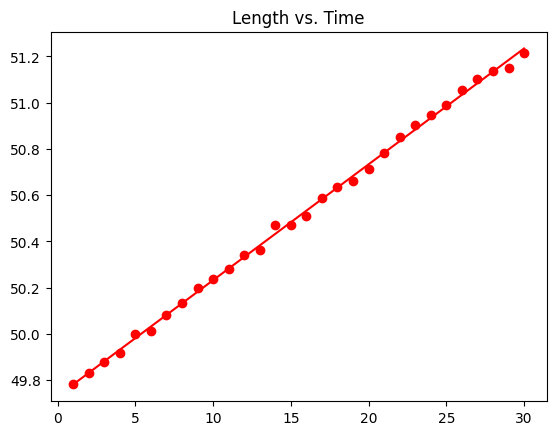

In [22]:
plt.title("Weight vs. Time")
plt.plot(range(1, 31), mean_weights, "bo")
# Graphing our linear regression results.
plt.plot(range(1, 31), weight_time_lr.predict(X), "b-")
plt.show()

plt.title("Length vs. Time")
plt.plot(range(1, 31), mean_lengths, "ro")
plt.plot(range(1, 31), length_time_lr.predict(X), "r-")
plt.show()

We see we have a very nearly linear relationship.

### Gender

In [11]:
df_male = df[df["gender"]=="Male"]
df_female = df[df["gender"]=="Female"]

df_female

,baby_id,name,gender,gestational_age_weeks,birth_weight_kg,birth_length_cm,birth_head_circumference_cm,date,age_days,weight_kg,...,oxygen_saturation,feeding_type,feeding_frequency_per_day,urine_output_count,stool_count,jaundice_level_mg_dl,apgar_score,immunizations_done,reflexes_normal,risk_level
29,B001,Sara,Female,40.2,3.30,50.0,31.9,2025-01-08,30,4.26,...,97,Mixed,7,6,2,5.2,NaN,Yes,No,Healthy
59,B002,Nicole,Female,39.4,3.15,50.1,32.0,2025-08-26,30,4.05,...,97,Formula,10,9,0,2.1,NaN,Yes,No,Healthy
209,B007,Michael,Female,39.9,3.62,51.0,35.2,2025-09-06,30,4.47,...,99,Formula,8,7,5,1.7,NaN,Yes,Yes,Healthy
269,B009,Christopher,Female,41.4,3.18,48.3,32.7,2025-07-24,30,4.12,...,97,Mixed,11,4,5,4.0,NaN,Yes,Yes,Healthy
329,B011,Mary,Female,37.0,2.18,51.4,38.1,2024-10-15,30,3.08,...,98,Mixed,11,9,3,4.0,NaN,Yes,Yes,Healthy
389,B013,Michael,Female,39.5,3.01,50.6,34.8,2025-05-12,30,4.02,...,98,Mixed,12,6,4,3.0,NaN,Yes,Yes,Healthy
479,B016,Stephen,Female,37.9,3.78,49.3,34.5,2025-03-11,30,4.65,...,96,Breastfeeding,12,6,5,3.6,NaN,Yes,Yes,Healthy
569,B019,Robin,Female,38.8,3.40,49.2,35.7,2025-03-15,30,4.24,...,97,Mixed,8,4,3,1.5,NaN,Yes,Yes,Healthy
629,B021,Jasmine,Female,38.9,2.16,48.5,33.9,2025-06-01,30,3.03,...,97,Mixed,12,5,5,3.8,NaN,Yes,Yes,Healthy
659,B022,Zachary,Female,39.7,2.88,46.3,37.5,2024-10-25,30,3.70,...,98,Breastfeeding,7,6,5,4.0,NaN,Yes,Yes,Healthy


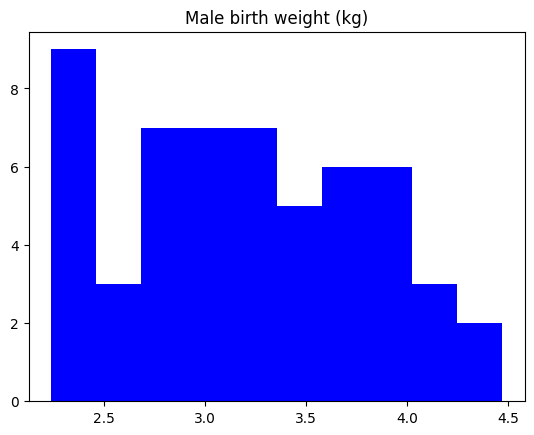

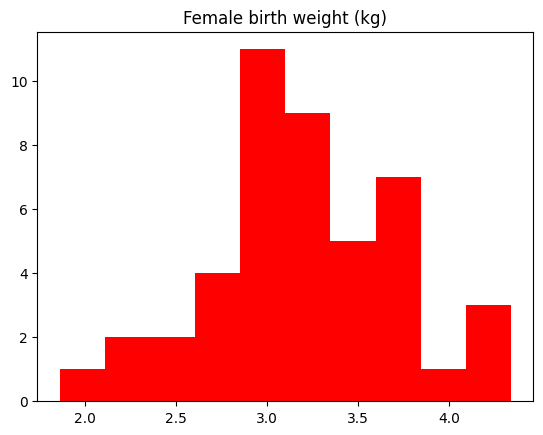

In [12]:
plt.title("Male birth weight (kg)")
plt.hist(df_male["birth_weight_kg"], color="blue")
plt.show()

plt.title("Female birth weight (kg)")
plt.hist(df_female["birth_weight_kg"], color="red")
plt.show()

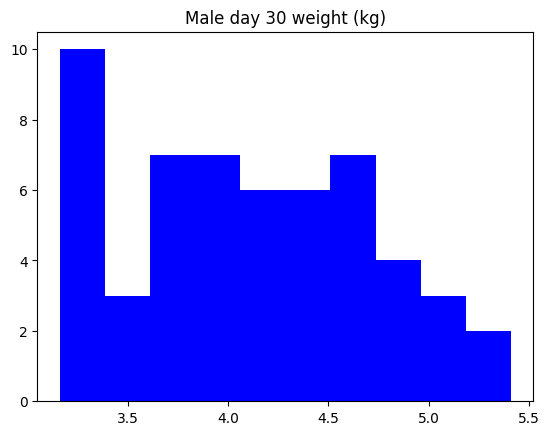

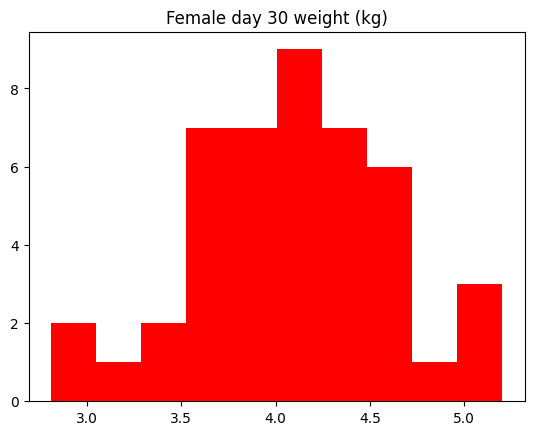

In [13]:
plt.title("Male day 30 weight (kg)")
plt.hist(df_male["weight_kg"], color="blue")
plt.show()

plt.title("Female day 30 weight (kg)")
plt.hist(df_female["weight_kg"], color="red")
plt.show()

We have four variables we want to look at:
1. Male birth weight
2. Female birth weight
3. Male day 30 weight
4. Female day 30 weight

We want to compare weight between genders at birth and day 30 separately. First, we will perform an $F$-test to see if the variances are statistically significantly different:
$$\begin{align*}
&H_0: \text{The variances between the two populations are different}\\
&H_1: \text{Not }H_0
\end{align*}$$
We will use $\alpha=0.05$.

In [15]:
# F-tests
alpha = 0.05

# Calculate sample variance for each of the four.
male_birth_weight_variance = np.var(df_male["birth_weight_kg"], ddof=1)
female_birth_weight_variance = np.var(df_female["birth_weight_kg"], ddof=1)
male_day30_weight_variance = np.var(df_male["weight_kg"], ddof=1)
female_day30_weight_variance = np.var(df_female["weight_kg"], ddof=1)

# Calculate F-statistics
# Male (numerator) vs. Female (denominator)
birth_weight_f = male_birth_weight_variance / female_birth_weight_variance
day30_weight_f = male_day30_weight_variance / female_day30_weight_variance
print(f"Birth F-statistic: {birth_weight_f}")
print(f"Day 30 F-statistic: {day30_weight_f}")

# Calculate critical F-values
# Note that both tests use the same critical value.
male_df = len(df_male) - 1
female_df = len(df_female) - 1
critical_f = stats.f.ppf(1 - alpha, male_df, female_df)
print()
print(f"Critical F-value: {critical_f}")

Birth f-statistic: 1.2504304844240093
Day 30 f-statistic: 1.294842906349364

Critical f-value: 1.6222987229992185


We see that the $F$-statistics are less than the critical $F$-value, so we do not reject the null hypothesis for any test.

We would now like to compare populations means, using the same $\alpha$. We will assume (due to the $F$-test) that the population variances are equal. Our new hypotheses are
$$\begin{align*}
&H_0: \text{The population means are the same}\\
&H_1: \text{Not }H_0
\end{align*}$$

In [17]:
# t-tests

male_mean_birth_weight = np.mean(df_male["birth_weight_kg"])
female_mean_birth_weight = np.mean(df_female["birth_weight_kg"])
male_mean_day30_weight = np.mean(df_male["weight_kg"])
female_mean_day30_weight = np.mean(df_female["weight_kg"])

# Calculating t-statistics.
sp2_birth_weight = (male_df * male_birth_weight_variance + female_df * female_birth_weight_variance) / (male_df + female_df)
sp2_day30_weight = (male_df * male_day30_weight_variance + female_df * female_day30_weight_variance) / (male_df + female_df)

birth_weight_t = (male_mean_birth_weight - female_mean_birth_weight) / np.sqrt(sp2_birth_weight * (1/male_df + 1/female_df))
day30_weight_t = (male_mean_day30_weight - female_mean_day30_weight) / np.sqrt(sp2_day30_weight * (1/male_df + 1/female_df))
print(f"Birth t-statistic: {birth_weight_t}")
print(f"Day 30 t-statistic: {day30_weight_t}")

# Calculating t-critical values.
# Again, note that it will be the same for both.
# Two-sided test, so take alpha/2.
t_critical = stats.t.ppf(1 - alpha/2, male_df + female_df)
print()
print(f"Critical t-value: {t_critical}")

Birth t-statistic: 0.2579085792599043
Day 30 t-statistic: 0.24135048626435168

Critical t-value: 1.984467454426692


We see that the absolute values of the test statistics do not exceed the critical value. We do not reject either null hypothesis here.

We'd like to repeat everything we've done so far but for length this time.

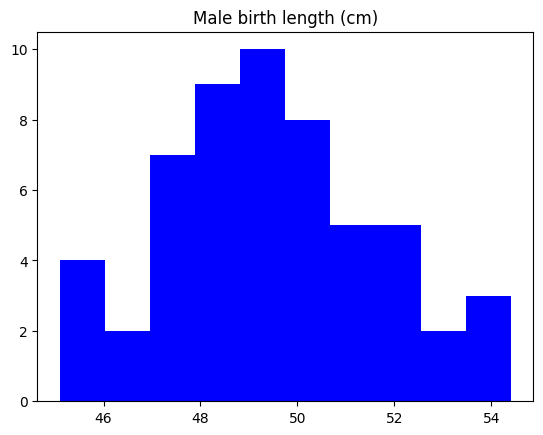

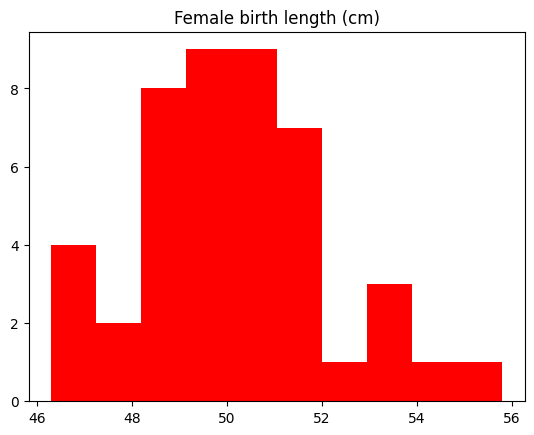

In [18]:
plt.title("Male birth length (cm)")
plt.hist(df_male["birth_length_cm"], color="blue")
plt.show()

plt.title("Female birth length (cm)")
plt.hist(df_female["birth_length_cm"], color="red")
plt.show()

In [19]:
# F-tests

# Calculate sample variance for each of the four.
male_birth_length_variance = np.var(df_male["birth_length_cm"], ddof=1)
male_day30_length_variance = np.var(df_male["length_cm"], ddof=1)
female_birth_length_variance = np.var(df_female["birth_length_cm"], ddof=1)
female_day30_length_variance = np.var(df_female["length_cm"], ddof=1)

# Calculate F-statistics.
# Like before, male is numerator and female is denominator.
birth_length_f = male_birth_length_variance / female_birth_length_variance
day30_length_f = male_day30_length_variance / female_day30_length_variance
print(f"Birth F-statistic: {birth_length_f}")
print(f"Day 30 F-statistic: {day30_length_f}")

# We can reuse the critical F-values from the previous test.
print()
print(f"Critical F-value: {critical_f}")

Birth F-statistic: 1.1749714994877125
Day 30 F-statistic: 1.176022398451466

Critical F-value: 1.6222987229992185


We do not reject either null hypothesis.

In [20]:
# t-tests

male_mean_birth_length = np.mean(df_male["birth_length_cm"])
female_mean_birth_length = np.mean(df_female["birth_length_cm"])
male_mean_day30_length = np.mean(df_male["length_cm"])
female_mean_day30_length = np.mean(df_female["length_cm"])

# t-statistics
sp2_birth_length = (male_df * male_birth_length_variance + female_df * female_birth_length_variance) / (male_df + female_df)
sp2_day30_length = (male_df * male_day30_length_variance + female_df * female_day30_length_variance) / (male_df + female_df)

birth_length_t = (male_mean_birth_length - female_mean_birth_length) / np.sqrt(sp2_birth_length * (1/male_df + 1/female_df))
day30_length_t = (male_mean_day30_length - female_mean_day30_length) / np.sqrt(sp2_day30_length * (1/male_df + 1/female_df))

print(f"Birth t-statistic: {birth_length_t}")
print(f"Day 30 t-statistic: {day30_length_t}")
print()
print(f"Critical t-value: {t_critical}")

Birth t-statistic: -1.3614654397103674
Day 30 t-statistic: -1.4203772799730032

Critical t-value: 1.984467454426692


The absolute values of our t-statistics are less than the critical value, so do not reject either null hypothesis.